# Learned expectations — SAC learning over a virtualized history

Poledna's eq. 6 and 9 do not hand agents an expected growth rate. They make expectations a
**regression on the model's own past**: every quarter, firms and households re-estimate an AR(1)
on the series the simulation has produced so far (Hommes & Zhu 2014, *sample-autocorrelation
learning*).

A SPARQL update rule cannot do that. The graph holds one time slice — the present — so a rule
needing `t-1` has to have stashed it there itself. `behaviour.macro.centralbank_rate` does
exactly that with `def:prev_output` / `def:prev_price`, and that hand-rolled one-lag memory is as
far as the trick scales.

So history goes where time series belong: a database.

| | |
|---|---|
| **store** | a DuckDB table, one row per tracked aggregate per tick |
| **expose** | maplib's chrontext virtualization maps it back into SPARQL |
| **compute** | a polars UDF, registered through the existing `udfs=` seam |
| **apply** | a SPARQL `SELECT`, passed through `history_rules=` |

Nothing in `skabm.history` knows what SAC learning is. It records aggregates and writes back
whatever a history rule computes — the last section swaps SAC for a different estimator without
touching the engine.

In [1]:
import matplotlib.pyplot as plt
import polars as pl
import polars_random as pr

from skabm.behaviour.params import poledna_params
from skabm.simulation import RDFSimulator

N_FIRMS, N_HOUSEHOLDS, N_GOV, N_FOREIGN = 50, 500, 3, 10

pr.set_random_seed(0)
firms = (
    pl.DataFrame({
        "id": [f"firm_{i}" for i in range(N_FIRMS)],
        "size": pr.normal(100.0, 30.0, size=N_FIRMS).clip(10, None).round(0),
        "alpha": 1.0, "w_bar": 1.0, "tech_share": 0.1,
        "price": 1.0, "margin": 0.2, "liquidity": 0.0,
    })
    .with_columns(pl.col("size").cast(pl.Float64))
    .with_columns(output=pl.col("size") * pl.col("alpha") * 0.9)
    .with_columns(profit=0.2 * pl.col("output"))
)

pr.set_random_seed(1)
households = pl.DataFrame({
    "id": [f"hh_{i}" for i in range(N_HOUSEHOLDS)],
    "psi": 0.9,
    "income": (pr.uniform(0.5, 2.0, size=N_HOUSEHOLDS) * 10.0).round(2),
})

governments = pl.DataFrame({
    "id": [f"gov_{i}" for i in range(N_GOV)],
    "budget": [50.0] * N_GOV, "tax_rate": 0.2134,
})
foreign_firms = pl.DataFrame({
    "id": [f"foreign_{i}" for i in range(N_FOREIGN)], "demand_size": [20.0] * N_FOREIGN,
})
central_bank = pl.DataFrame({
    "id": ["central_bank"], "policy_rate": [0.009], "inflation_target": [0.005],
    "prev_output": [float(firms["output"].sum())], "prev_price": [1.0],
})

populations = dict(
    Firm=firms, Household=households, Government=governments,
    ForeignFirm=foreign_firms, CentralBank=central_bank,
)

params = {
    **poledna_params,
    "total_deposits": 2000.0,
    "firm_ownership_ratio": N_FIRMS / N_HOUSEHOLDS,
    # Expectations are learned from the model's own history, not parameterised.
    # A cold run starts with an empty history, so the opening forecast is zero
    # and a fully deterministic economy would sit still; the shocks below are
    # what give the AR(1) something to estimate.  See 03_sac_learning.ipynb.
    "growth_sigma": 0.02,
    "inflation_sigma": 0.01,
}
firms.head(3)

id,size,alpha,w_bar,tech_share,price,margin,liquidity,output,profit
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""firm_0""",85.0,1.0,1.0,0.1,1.0,0.2,0.0,76.5,15.3
"""firm_1""",137.0,1.0,1.0,0.1,1.0,0.2,0.0,123.3,24.66
"""firm_2""",60.0,1.0,1.0,0.1,1.0,0.2,0.0,54.0,10.8


## Declaring a signal is the whole opt-in

`behaviour.learning.expect` produces one ordinary triple pattern. The `ex:sig__…` IRI in it is the
detection hook: `history.parse_signals` reads it straight off the rendered rule text, and the
simulator starts recording that aggregate. Nothing is registered anywhere else, and a rule set
that never mentions a signal opens no database at all.

In [2]:
from skabm.behaviour.learning import expect, sac_learning
from skabm.history import parse_signals, state_frame

fragment = expect("SUM", "Firm", "output", out="g_e")
print(fragment)
print("detected signals:", parse_signals([fragment]))


    OPTIONAL { ex:sig__SUM__Firm__output def:forecast ?g_e__learned }
    BIND(IF(BOUND(?g_e__learned), ?g_e__learned, 0e0) AS ?g_e)

detected signals: [('SUM', 'Firm', 'output')]


That is what `firm_produce` splices in, so the *behaviour* rule stays graph-local — it reads a
plain `def:forecast` triple and never touches the database:

In [3]:
from skabm.behaviour.firm import firm_produce

print(firm_produce.template.split("WHERE {")[1].split("}")[0])


    ?f a ex:Firm ;
        def:output ?y0 ;
        def:alpha ?alpha ;
        def:size ?n .
    OPTIONAL { ex:sig__SUM__Firm__output def:forecast ?g_e__learned 


## The history rule

One federated SELECT per tick. `?sig ct:hasTimeseries …` resolves through the virtualization into
DuckDB rows; `sac:forecast` is the polars UDF; `SAMPLE` collapses the per-row broadcast it returns
to one row per signal.

Two details are load-bearing:

* **`ORDER BY ?ext ?t`** — rows reach a UDF in *database* order, not time order. chrontext pushes
  this sort down into SQL. Drop it and the query still returns a number, just one fitted to a
  shuffled series.
* **the projection** — first variable is the subject IRI, the rest become `def:` predicates on it.
  That is `history`'s generic write-back contract, not anything SAC-specific.

In [4]:
print(sac_learning.template)

PREFIX ex:<http://example.net/skabm#>
PREFIX def:<urn:maplib_default:>
PREFIX pr:<urn:pr:>
PREFIX math:<urn:math:>
PREFIX xsd:<http://www.w3.org/2001/XMLSchema#>
PREFIX ct:<https://github.com/DataTreehouse/chrontext#>
PREFIX sac:<urn:sac:>

SELECT ?sig (SAMPLE(?f) AS ?forecast)
WHERE {
    { SELECT ?sig ?ext ?t ?v
      WHERE {
          ?sig ct:hasTimeseries ?tsn .
          ?tsn ct:hasExternalId ?ext ;
               ct:hasDataPoint ?dp .
          ?dp ct:hasTimestamp ?t ;
              ct:hasValue ?v .
      }
      ORDER BY ?ext ?t }
    BIND(sac:forecast(?ext, ?t, ?v) AS ?f)
}
GROUP BY ?sig



## Run, tracking belief against realization

In [5]:
FORECASTS = """
PREFIX ex: <http://example.net/skabm#>
PREFIX def: <urn:maplib_default:>
SELECT ?sig ?f WHERE { ?sig def:forecast ?f }
"""

sim = RDFSimulator(params=params, n_periods=24, random_seed=0)

beliefs = []
for t, _ in enumerate(sim.fit_iter(**populations)):
    published = {
        iri.rsplit("#", 1)[-1].rstrip(">"): f
        for iri, f in zip(*sim.model_.query(FORECASTS).get_columns())
    }
    beliefs.append({"t": t, **published})

beliefs = pl.DataFrame(beliefs)
beliefs.head()

t,sig__AVG__Firm__price,sig__SUM__Firm__output,sig__SUM__Household__income
i64,f64,f64,f64
0,-0.001561,0.002337,-0.877622
1,-0.001884,0.00125,-0.816678
2,-0.002269,-0.000032,-0.579449
3,-0.001977,0.003653,-0.316683
4,-0.002775,-0.003541,-0.197604


The DuckDB table itself — this is the whole memory, one row per signal per tick, and it is a
plain table you can query with SQL or hand to polars:

In [6]:
history = state_frame(sim.connection_)
print(history.head(6))
print(f"\n{history.height} rows across {history['signal'].n_unique()} signals")

shape: (6, 3)
┌───────────────────────┬─────┬──────────┐
│ signal                ┆ t   ┆ level    │
│ ---                   ┆ --- ┆ ---      │
│ str                   ┆ i32 ┆ f64      │
╞═══════════════════════╪═════╪══════════╡
│ sig__AVG__Firm__price ┆ 0   ┆ 1.0      │
│ sig__AVG__Firm__price ┆ 1   ┆ 0.998439 │
│ sig__AVG__Firm__price ┆ 2   ┆ 0.99559  │
│ sig__AVG__Firm__price ┆ 3   ┆ 0.993951 │
│ sig__AVG__Firm__price ┆ 4   ┆ 0.989002 │
│ sig__AVG__Firm__price ┆ 5   ┆ 0.985763 │
└───────────────────────┴─────┴──────────┘

75 rows across 3 signals


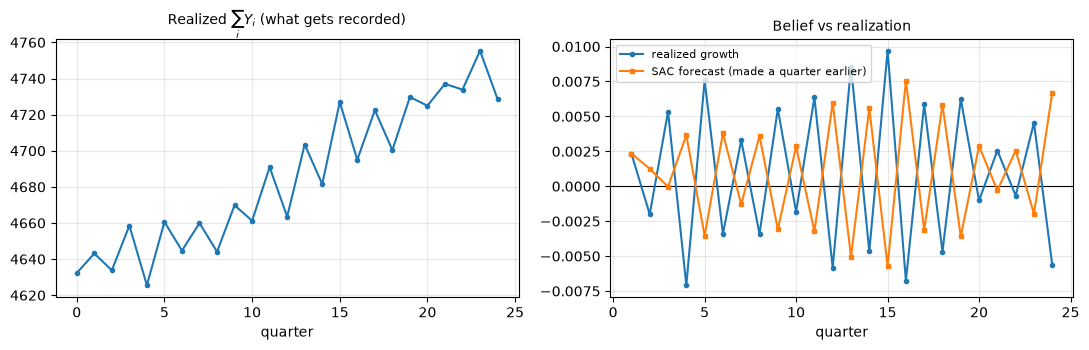

In [7]:
realized = (
    history.filter(pl.col("signal") == "sig__SUM__Firm__output")
    .sort("t")
    .with_columns(growth=pl.col("level") / pl.col("level").shift(1) - 1.0)
)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))
left.plot(realized["t"], realized["level"], marker="o", ms=3)
left.set_title("Realized $\\sum_i Y_i$ (what gets recorded)", fontsize=10)
left.set_xlabel("quarter"); left.grid(alpha=0.3)

right.axhline(0, c="k", lw=0.8)
right.plot(realized["t"], realized["growth"], marker="o", ms=3, label="realized growth")
right.plot(beliefs["t"] + 1, beliefs["sig__SUM__Firm__output"],
           marker="s", ms=3, label="SAC forecast (made a quarter earlier)")
right.set_title("Belief vs realization", fontsize=10)
right.set_xlabel("quarter"); right.legend(fontsize=8); right.grid(alpha=0.3)
fig.tight_layout()

## No prior, and what follows from that

There is no "expected growth" parameter any more. A cold run starts with an empty history, so the
opening forecast is nothing at all; the `OPTIONAL`/`BOUND` pair in `expect` falls back to `0e0`,
a structural zero rather than a tunable belief.

That has a consequence worth seeing plainly: **a fully deterministic run never leaves its initial
state.** Expected growth is zero, so realized growth is zero, so the estimate stays zero. Growth
has to come from somewhere real — shocks here, or a pre-seeded history.

Poledna never faces this, because the model is initialised from actual Austrian series and the
regression has data from the first quarter. Seeding the DuckDB table with real history before
fitting is the faithful fix; `duckdb_connection=` takes a path or a live connection for exactly
that.

In [8]:
flat = RDFSimulator(params={**params, "growth_sigma": 0.0, "inflation_sigma": 0.0},
                    n_periods=6).fit(**populations)
levels = state_frame(flat.connection_).filter(pl.col("signal") == "sig__SUM__Firm__output")
print("deterministic run, recorded output levels:", levels["level"].round(2).to_list())

deterministic run, recorded output levels: [4632.3, 4632.3, 4632.3, 4632.3, 4632.3, 4632.3, 4632.3]


## The seam is generic

`skabm.history` records aggregates and writes back result columns. *What* is computed is a query
plus a UDF, so swapping the estimator means writing another pair — no engine change.

Here is naive adaptive expectations (mean growth so far) replacing SAC, wired through the same
two arguments `RDFSimulator` already had.

In [9]:
from maplib import xsd
from skabm.history import CT_NS
from skabm.rules import _PREFIXES, register_polars_random


def mean_growth(df: pl.DataFrame) -> pl.Series:
    """Average growth so far — same contract as behaviour.learning.sac_forecast."""
    key, _, level = df.columns[:3]
    growth = pl.col(level) / pl.col(level).shift(1).over(key) - 1.0
    return (
        df.with_columns(g=growth)
        .select(out=pl.col("g").mean().over(key).cast(pl.Float64))["out"]
        .alias("out")
    )


def register_mean_growth(model):
    model.add_udf("urn:ma:forecast", mean_growth, xsd.double,
                  [xsd.string, xsd.dateTime, xsd.double])


mean_growth_rule = _PREFIXES + f"PREFIX ct:<{CT_NS}>\nPREFIX ma:<urn:ma:>\n" + """
SELECT ?sig (SAMPLE(?f) AS ?forecast)
WHERE {
    { SELECT ?sig ?ext ?t ?v WHERE {
        ?sig ct:hasTimeseries ?tsn .
        ?tsn ct:hasExternalId ?ext ; ct:hasDataPoint ?dp .
        ?dp ct:hasTimestamp ?t ; ct:hasValue ?v .
      } ORDER BY ?ext ?t }
    BIND(ma:forecast(?ext, ?t, ?v) AS ?f)
}
GROUP BY ?sig
"""

adaptive = RDFSimulator(
    params=params,
    udfs=(register_polars_random, register_mean_growth),
    history_rules=(mean_growth_rule,),
    n_periods=24,
    random_seed=0,
)
adaptive.fit(**populations)
adaptive.model_.query(FORECASTS)

sig,f
str,f64
"""<http://example.net/skabm#sig_…",-0.002387
"""<http://example.net/skabm#sig_…",0.000971
"""<http://example.net/skabm#sig_…",-0.072749


Same populations, same behaviour rules, same seed — a different theory of how agents form
expectations, expressed entirely as SPARQL and polars. That is the property that matters: the
simulator knows only *"run these queries against the history, write back their columns"*.

### Two chrontext limits worth knowing

Both fail **silently**, and `tests/test_history.py` pins them:

1. **Only `Model.query` federates.** `update` and `insert` see virtualized data as empty and
   quietly no-op; `query` with CONSTRUCT panics. That is why forecasts are written back as plain
   triples instead of being read directly by the behaviour rules.
2. **Registering a virtualization nulls graph-local aggregates on that model.** After
   `add_virtualization`, `SELECT (SUM(?x) …)` returns `None` where it returned a number — including
   inside sub-SELECTs, which `firm_sales` and `centralbank_rate` are built from. So the
   virtualization lives on a separate learner model and never touches `model_`.